# **Q3 and Q4**

# **Q3**

To build prediction model effectively, only information available at the point of loan origination is used; 18 features were selected

**Feature engineering:**

14 numeric features (loan terms *['loan_amnt', 'term', 'int_rate', 'installment']*, borrower financials *['emp_length', 'annual_inc', 'dti']*, credit history *['delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc']*)

24 one-hot encoded categorical features (grade, purpose, home ownership, verification status) — drop_first=True avoids multicollinearity


**Loss Funtion:**

BCELoss is used since it is suitable for binary classification

## 1.Import, Clean, Data split

### 1.1 Import Library

In [1]:
!pip install torch torchvision torchaudio imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay as CM
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


### 1.2 Load in dataset

In [3]:
# Load dataset
data = pd.read_csv('early_2012_2013_loan_sample_with_outcome.csv')

### 1.3 Data type, Encoding, and imputation

In [4]:
# Changing Data type
# Target variable - convert categorical data to integer where loan_is_bad = 1 is loan default
data['loan_is_bad'] = data['loan_is_bad'].astype(int)

# Fix revol_util - stored as a string percentage e.g. "66.20%"
data['revol_util'] = data['revol_util'].str.replace('%', '').astype(float)

In [5]:
# Display missing values before imputation
print("Missing values before imputation:")
missing_values = data.isnull().sum()
missing_values_percentage = (missing_values[missing_values > 0] / len(data)) * 100
missing_values_table = pd.DataFrame({
    'Missing Count': missing_values[missing_values > 0],
    'Missing Percentage': missing_values_percentage
})
display(missing_values_table.sort_values(by='Missing Percentage', ascending=False))

Missing values before imputation:


,Missing Count,Missing Percentage
mths_since_last_record,47468,94.936
mths_since_last_major_derog,42880,85.760
next_pymnt_d,42864,85.728
mths_since_last_delinq,28126,56.252
desc,18996,37.992
tot_cur_bal,14618,29.236
total_credit_rv,14618,29.236
tot_coll_amt,14618,29.236
emp_title,2832,5.664
emp_length,1802,3.604


In [6]:
# Missing values imputation
# Since only 'emp_length' and 'revol_util' variables will be used, impute only these 2 variables
# Fill missing values with median
data['emp_length'] = data['emp_length'].fillna(data['emp_length'].median())
data['revol_util'] = data['revol_util'].fillna(data['revol_util'].median())

In [7]:
# One-hot encode categorical columns
# drop_first=True removes one dummy per group to avoid multicollinearity
cat_cols = ['grade', 'home_ownership', 'verification_status', 'purpose']
data_enc = pd.get_dummies(data, columns=cat_cols, drop_first=True)

# Feature selection - only columns available at loan origination (no post-loan data)
num_features = ['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length',
                'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths',
                'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc']

cat_features = [c for c in data_enc.columns if any(c.startswith(p + '_') for p in cat_cols)]

all_features = num_features + cat_features

### 1.4 Train/Val/Test Splitting

In [8]:
# Store target variable seperately for data splitting
X = data_enc[all_features].values.astype(np.float32)
y = data_enc['loan_is_bad'].values.astype(np.float32)

print(f'Features: {len(all_features)}')
print(data['loan_is_bad'].value_counts())
print(all_features)

Features: 38
loan_is_bad
0    42186
1     7814
Name: count, dtype: int64
['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'grade_B', 'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation', 'purpose_wedding']


In [ ]:
# Shared 3-way split – all three models use the same train/val/test sets
# 70% train / 15% val / 15% test  (0.1765 ≈ 0.15 / 0.85 for the second call)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, random_state=42, stratify=y_trainval)

print(f'Train: {len(X_train)}   Val: {len(X_val)}   Test: {len(X_test)}')
print(f'Test default rate: {y_test.mean():.3f}')


### 1.5 Standardize Features

Features are standardized once here, shared across all three models. The scaler is **fit only on the training set** to prevent data leakage into the validation and test sets.

In [ ]:
# Standardize features – fit on training data only, transform val and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {len(X_train_scaled)}, Val: {len(X_val_scaled)}, Test: {len(X_test_scaled)}')


### 1.6 Data Balancing

SMOTE is applied once to the shared **standardized** training set to balance the class imbalance. Applied to scaled data so synthetic samples are generated in the same feature space as the real data.

In [ ]:
# Apply SMOTE once on the standardized training set – shared by all three models
random_seed  = 123
target_ratio = 0.67   # minority/majority

smote = SMOTE(sampling_strategy=target_ratio, random_state=random_seed)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)

print('--- Before SMOTE Oversampling ---')
print(pd.Series(y_train).value_counts())
print('--- After SMOTE Oversampling ---')
print(pd.Series(y_smote).value_counts())


### 1.7 Cluster Segmentation from Q2

4 clusters from Q2 were obtained for model evalutation per segment

In [10]:
# Rebuild Q2 cluster labels - replace with data['cluster'].values if you saved them
grade_map = {'A':0,'B':1,'C':2,'D':3,'E':4,'F':5,'G':6}
data['grade_num'] = data['grade'].map(grade_map)
dti_med = data['dti'].median()

data['cluster'] = np.select(
    [
        (data['grade_num'] <= 1) & (data['dti'] <  dti_med),   # Cluster 0: Prime
        (data['grade_num'] <= 1) & (data['dti'] >= dti_med),   # Cluster 1: Near-Prime
        (data['grade_num'].between(2, 3)),                      # Cluster 2: Sub-Prime
        (data['grade_num'] >= 4),                               # Cluster 3: High-Risk
    ],
    [0, 1, 2, 3], default=2
)

cluster_names = {
    0: 'Cluster 0: Prime',
    1: 'Cluster 1: Near-Prime',
    2: 'Cluster 2: Sub-Prime',
    3: 'Cluster 3: High-Risk'
}

print(data.groupby('cluster').agg(N=('loan_is_bad','count'), Default_Rate=('loan_is_bad','mean')).round(3))

# Keep test-set cluster labels aligned to the same split
_, idx_test = train_test_split(np.arange(len(data)), test_size=0.15, random_state=42, stratify=y)
clusters_test = data['cluster'].values[idx_test]


             N  Default_Rate
cluster                     
0        14341         0.089
1        12051         0.121
2        19236         0.198
3         4372         0.294


---
## 2.Optimised DNN


**Extra improvements:**
- 3-layer architecture for more expressive power
- Increamental to 10 epochs to give the model more room to improve
- Data is splitted into 3 sets; training, validation, and test sets

In [ ]:
opt_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {opt_device}')

### 2.1 OP_DNN - Data Setup

In [ ]:
# Use shared pre-scaled arrays from section 1.5
X_smote_op_dnn = X_smote
X_val_op_dnn   = X_val_scaled
X_test_op_dnn  = X_test_scaled
y_smote_op_dnn = y_smote
y_val_op_dnn   = y_val

print(f'Train (SMOTE\'d): {len(X_smote_op_dnn)}, Val: {len(X_val_op_dnn)}, Test: {len(X_test_op_dnn)}')

### 2.2 OP_DNN - Build Model

In [15]:
# Convert to PyTorch tensors
# FloatTensor for y because we use BCEWithLogitsLoss (binary), not CrossEntropyLoss (multiclass)
X_smote_op_dnn = torch.FloatTensor(X_smote_op_dnn)
y_smote_op_dnn = torch.FloatTensor(y_smote_op_dnn).unsqueeze(1)
X_val_op_dnn   = torch.FloatTensor(X_val_op_dnn)
y_val_op_dnn   = torch.FloatTensor(y_val_op_dnn).unsqueeze(1)
X_test_op_dnn  = torch.FloatTensor(X_test_op_dnn)
y_test_op_dnn  = torch.FloatTensor(y_test).unsqueeze(1)


In [16]:
# Tensors & DataLoaders
batch_size = 64
train_loader_opt = DataLoader(TensorDataset(X_smote_op_dnn, y_smote_op_dnn), batch_size=batch_size, shuffle=True)
val_loader_opt   = DataLoader(TensorDataset(X_val_op_dnn,   y_val_op_dnn),   batch_size=batch_size, shuffle=False)
test_loader_opt  = DataLoader(TensorDataset(X_test_op_dnn,  y_test_op_dnn),  batch_size=batch_size, shuffle=False)

print(f'Train: {len(X_smote_op_dnn)}, Val: {len(X_val_op_dnn)}, Test: {len(X_test_op_dnn)}')


Train: 40607, Val: 6178, Test: 7500


In [17]:
# Define AdvancedDNN with BatchNorm + Dropout
class AdvancedDNN(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.3):
        super(AdvancedDNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(64, 32),         nn.BatchNorm1d(32),  nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(32, 1)           # single logit output - sigmoid applied outside
        )

    def forward(self, x):
        return self.network(x)

opt_model = AdvancedDNN(input_dim=X_smote_op_dnn.shape[1]).to(opt_device)
print(opt_model)


AdvancedDNN(
  (network): Sequential(
    (0): Linear(in_features=38, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [18]:
# pos_weight upweights the default class in the loss to handle class imbalance
# ratio = number of negatives / number of positives in training set
#neg_count = int((y_smote_op_dnn == 0).sum())
#pos_count = int((y_smote_op_dnn == 1).sum())
#pos_weight = torch.tensor([neg_count / pos_count], dtype=torch.float32).to(opt_device)
#print(f'pos_weight: {pos_weight.item():.3f}')

opt_criterion = nn.BCEWithLogitsLoss()
# AdamW adds weight decay directly to the weight update rule for better regularization
opt_optimizer = optim.AdamW(opt_model.parameters(), lr=0.001, weight_decay=1e-4)
# Learning Rate Decay: Reduces LR when validation loss plateaus
opt_scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt_optimizer, mode='min', factor=0.5, patience=5)


In [19]:
# Training loop with early stopping
epochs        = 150
patience_opt  = 10
best_val_loss = float('inf')
epochs_no_imp = 0
early_stop    = False
train_losses, val_losses = [], []

for epoch in range(epochs):
    if early_stop:
        print(f'Early stopping triggered at epoch {epoch}')
        break

    # Training phase
    opt_model.train()
    running_loss = 0.0
    for inputs, labels in train_loader_opt:
        inputs, labels = inputs.to(opt_device), labels.to(opt_device)
        opt_optimizer.zero_grad()
        loss = opt_criterion(opt_model(inputs), labels)
        loss.backward()
        opt_optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    epoch_train_loss = running_loss / len(train_loader_opt.dataset)
    train_losses.append(epoch_train_loss)

    # Validation phase
    opt_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader_opt:
            inputs, labels = inputs.to(opt_device), labels.to(opt_device)
            val_loss += opt_criterion(opt_model(inputs), labels).item() * inputs.size(0)
    epoch_val_loss = val_loss / len(val_loader_opt.dataset)
    val_losses.append(epoch_val_loss)

    opt_scheduler.step(epoch_val_loss)

    # Early stopping - save best model so we can revert back
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_imp = 0
        torch.save(opt_model.state_dict(), 'best_model.pth')
    else:
        epochs_no_imp += 1
        if epochs_no_imp >= patience_opt:
            early_stop = True

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:03d}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}')


Epoch 010/150 | Train Loss: 0.5962 | Val Loss: 0.5388
Early stopping triggered at epoch 13


### 2.3 OP_DNN - Model Performance

Accuracy : 0.7251
Recall   : 0.4181
Precision: 0.262
F1 Score : 0.3222
AUC-ROC  : 0.655


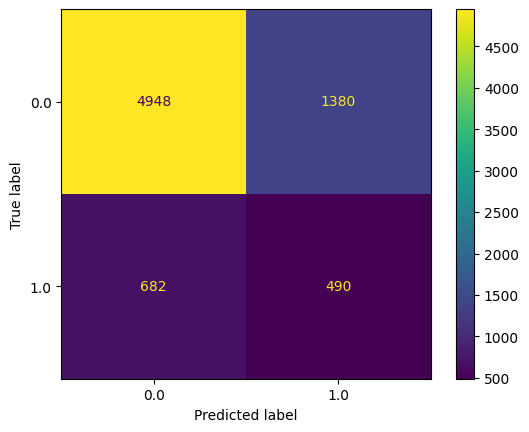

In [20]:
# Load best model and evaluate on test set
opt_model.load_state_dict(torch.load('best_model.pth'))
opt_model.eval()

all_probs_opt = []
with torch.no_grad():
    for inputs, labels in test_loader_opt:
        inputs  = inputs.to(opt_device)
        logits  = opt_model(inputs)
        probs   = torch.sigmoid(logits).cpu().numpy().flatten()
        all_probs_opt.extend(probs)

y_prob_opt = np.array(all_probs_opt)
y_pred_opt = (y_prob_opt >= 0.5).astype(int)

accuracy  = accuracy_score(y_test,  y_pred_opt)
recall    = recall_score(y_test,    y_pred_opt)
precision = precision_score(y_test, y_pred_opt, zero_division=0)
f1        = f1_score(y_test,        y_pred_opt, zero_division=0)
auc       = roc_auc_score(y_test,   y_prob_opt)

print(f'Accuracy : {round(accuracy,  4)}')
print(f'Recall   : {round(recall,    4)}')
print(f'Precision: {round(precision, 4)}')
print(f'F1 Score : {round(f1,        4)}')
print(f'AUC-ROC  : {round(auc,       4)}')

CM.from_predictions(y_test, y_pred_opt)


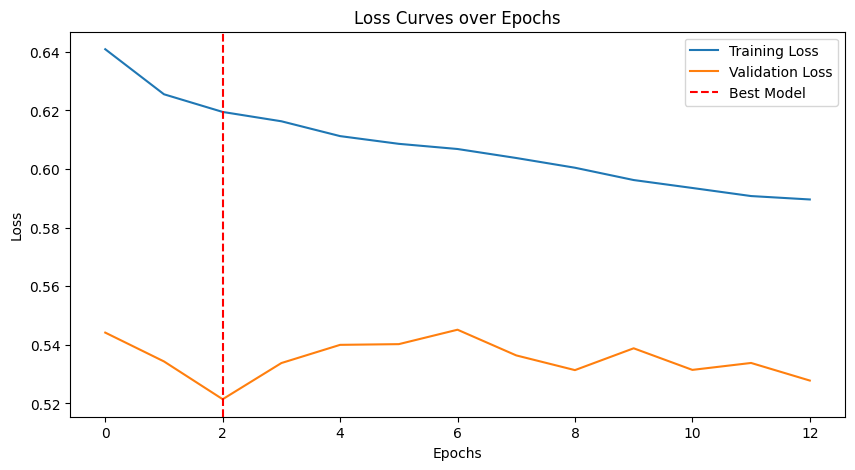

In [21]:
# Learning curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses,   label='Validation Loss')
plt.axvline(x=len(train_losses) - epochs_no_imp - 1, color='r', linestyle='--', label='Best Model')
plt.title('Loss Curves over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


## 3.Evaluate across borrower clusters in Q2

### 3.1 OP_DNN - Q2 Borrower Clusters


In [22]:
# Evaluate recall per cluster for Optimized DNN model
cluster_rows = []
for cl in sorted(np.unique(clusters_test)):
    mask = (clusters_test == cl)
    y_cl = y_test[mask]

    for model_name, y_prob in [('Optimised DNN',       y_prob_opt)]:
        p_cl = y_prob[mask]
        pred = (p_cl >= 0.5).astype(int)
        cluster_rows.append({
            'Cluster'   : cluster_names[cl],
            'Def. Rate' : f'{y_cl.mean()*100:.1f}%',
            'N'         : int(mask.sum()),
            'Model'     : model_name,
            'Recall'    : round(recall_score(y_cl, pred), 3),
            'F1'        : round(f1_score(y_cl, pred, zero_division=0), 3),
            'AUC-ROC'   : round(roc_auc_score(y_cl, p_cl) if y_cl.sum() > 0 else np.nan, 3),
        })

cluster_df = pd.DataFrame(cluster_rows)
print(cluster_df.to_string(index=False))


              Cluster Def. Rate    N         Model  Recall    F1  AUC-ROC
     Cluster 0: Prime      9.0% 2177 Optimised DNN   0.036 0.059    0.599
Cluster 1: Near-Prime     11.9% 1793 Optimised DNN   0.042 0.072    0.600
 Cluster 2: Sub-Prime     19.7% 2877 Optimised DNN   0.551 0.335    0.584
 Cluster 3: High-Risk     29.9%  653 Optimised DNN   0.826 0.471    0.578


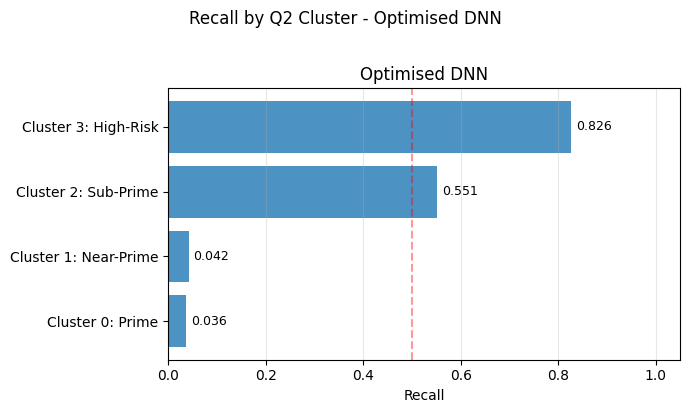

In [23]:
# Recall by cluster for OP_DNN
fig, ax = plt.subplots(figsize=(7, 4))
model_list = ['Optimised DNN']

for model_name in model_list:
    sub    = cluster_df[cluster_df['Model'] == model_name]
    labels = sub['Cluster'].values
    vals   = sub['Recall'].values
    ax.barh(labels, vals, alpha=0.8)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Recall')
    ax.set_title(model_name)
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.4)
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(v + 0.01, i, str(v), va='center', fontsize=9)

plt.suptitle('Recall by Q2 Cluster - Optimised DNN', y=1.02)
plt.tight_layout()
plt.show()

# Q4b

Policy Insights and Next Steps

## 1.Threshold sensitivity

In [24]:
# Threshold sensitivity - shows the trade-off between catching more defaults
# vs rejecting more good borrowers (using the Optimised DNN)
print('Threshold sensitivity for Optimised DNN:')
print(f'{"Threshold":<12} {"Recall":<10} {"Precision":<12} {"Approval Rate":<15}')
print('-' * 50)
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (y_prob_opt >= t).astype(int)
    rec  = recall_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    appr = 1 - pred.mean()
    print(f'{t:<12.1f} {rec:<10.3f} {prec:<12.3f} {appr*100:<15.1f}%')

print()
print('Lower threshold = catch more defaults but reject more good loans.')
print('A risk-averse lender should consider threshold = 0.4.')


Threshold sensitivity for Optimised DNN:
Threshold    Recall     Precision    Approval Rate  
--------------------------------------------------
0.3          0.768      0.200        40.1           %
0.4          0.619      0.233        58.5           %
0.5          0.418      0.262        75.1           %
0.6          0.065      0.299        96.6           %
0.7          0.007      0.364        99.7           %

Lower threshold = catch more defaults but reject more good loans.
A risk-averse lender should consider threshold = 0.4.


In [25]:
# Recommended cluster-specific thresholds based on Q2 default rates
print('Recommended thresholds by Q2 cluster:')
print()
thresholds = {
    'Cluster 0: Prime      (default rate  8.9%)' : 0.6,
    'Cluster 1: Near-Prime (default rate 12.1%)' : 0.5,
    'Cluster 2: Sub-Prime  (default rate 19.8%)' : 0.4,
    'Cluster 3: High-Risk  (default rate 29.4%)' : 0.3,
}
for cluster, threshold in thresholds.items():
    print(f'  {cluster}  ->  threshold = {threshold}')

print()
print('Next steps:')
print('  1. Deploy the Optimised DNN as a scoring engine to replace Q1 rule-based policies')
print('  2. Use cluster-specific thresholds above rather than a single global cutoff')
print('  3. Run a live A/B test: DNN policy vs Policy A from Q1 before full rollout')
print('  4. Re-train quarterly as new loan cohorts complete their lifecycle')
print('  5. Add external bureau data and macroeconomic features to improve recall on Cluster 3')


Recommended thresholds by Q2 cluster:

  Cluster 0: Prime      (default rate  8.9%)  ->  threshold = 0.6
  Cluster 1: Near-Prime (default rate 12.1%)  ->  threshold = 0.5
  Cluster 2: Sub-Prime  (default rate 19.8%)  ->  threshold = 0.4
  Cluster 3: High-Risk  (default rate 29.4%)  ->  threshold = 0.3

Next steps:
  1. Deploy the Optimised DNN as a scoring engine to replace Q1 rule-based policies
  2. Use cluster-specific thresholds above rather than a single global cutoff
  3. Run a live A/B test: DNN policy vs Policy A from Q1 before full rollout
  4. Re-train quarterly as new loan cohorts complete their lifecycle
  5. Add external bureau data and macroeconomic features to improve recall on Cluster 3


## 2.Model Building

### 2.1 Logistic Regression


#### 2.1.1 LR - Data Setup

In [ ]:
# Use shared pre-scaled arrays from section 1.5
X_smote_lr = X_smote
X_val_lr   = X_val_scaled
X_test_lr  = X_test_scaled
y_smote_lr = y_smote
y_val_lr   = y_val

print(f'Train (SMOTE\'d): {len(X_smote_lr)}, Val: {len(X_val_lr)}, Test: {len(X_test_lr)}')

#### 2.1.2 LR - Build Model

In [ ]:
# Convert to PyTorch tensors
X_smote_lr = torch.tensor(X_smote_lr, dtype=torch.float32)
X_val_lr   = torch.tensor(X_val_lr,   dtype=torch.float32)
X_test_lr  = torch.tensor(X_test_lr,  dtype=torch.float32)
y_smote_lr = torch.tensor(list(y_smote_lr), dtype=torch.float32).unsqueeze(1)
y_val_lr   = torch.tensor(list(y_val_lr),   dtype=torch.float32).unsqueeze(1)
y_test_lr  = torch.tensor(list(y_test),     dtype=torch.float32).unsqueeze(1)


In [29]:
# Define logistic regression model
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

# Initialize model, loss, optimizer
input_dim    = X_smote_lr.shape[1]
lr_model     = LogisticRegression(input_dim)

# Define loss and optimizer
lr_criterion = nn.BCELoss()
lr_optimizer = optim.SGD(lr_model.parameters(), lr=0.01)


In [ ]:
# Training loop with validation monitoring
epochs = 100

for epoch in range(epochs):
    # Training phase
    lr_model.train()
    lr_optimizer.zero_grad()
    outputs = lr_model(X_smote_lr)
    loss    = lr_criterion(outputs, y_smote_lr)
    loss.backward()
    lr_optimizer.step()

    # Validation phase
    lr_model.eval()
    with torch.no_grad():
        val_outputs = lr_model(X_val_lr)
        val_loss    = lr_criterion(val_outputs, y_val_lr)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], '
              f'Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}')


#### 2.1.3 LR - Model Performance

Accuracy : 0.606
Recall   : 0.4556
Precision: 0.1873
F1 Score : 0.2655
AUC-ROC  : 0.5587


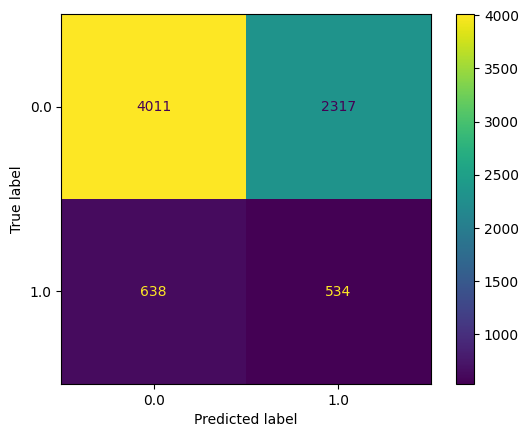

In [31]:
# Evaluation
lr_model.eval()
with torch.no_grad():
    y_prob_lr = lr_model(X_test_lr).numpy().flatten()
    y_pred_lr = (y_prob_lr >= 0.5).astype(float)

accuracy  = accuracy_score(y_test,  y_pred_lr)
recall    = recall_score(y_test,    y_pred_lr)
precision = precision_score(y_test, y_pred_lr, zero_division=0)
f1        = f1_score(y_test,        y_pred_lr, zero_division=0)
auc       = roc_auc_score(y_test,   y_prob_lr)

print(f'Accuracy : {round(accuracy,  4)}')
print(f'Recall   : {round(recall,    4)}')
print(f'Precision: {round(precision, 4)}')
print(f'F1 Score : {round(f1,        4)}')
print(f'AUC-ROC  : {round(auc,       4)}')

CM.from_predictions(y_test, y_pred_lr)


---
### 2.2 Dense Neural Network (DNN)


In [32]:
# Check for GPU availability
print('Num GPUs Available:', torch.cuda.device_count())


Num GPUs Available: 0


#### 2.2.1 DNN - Data Setup

In [ ]:
# Use shared pre-scaled arrays from section 1.5
X_smote_dnn = X_smote
X_val_dnn   = X_val_scaled
X_test_dnn  = X_test_scaled
y_smote_dnn = y_smote
y_val_dnn   = y_val

print(f'Train (SMOTE\'d): {len(X_smote_dnn)}, Val: {len(X_val_dnn)}, Test: {len(X_test_dnn)}')

#### 2.2.2 DNN - Build Model

In [ ]:
# Convert data to PyTorch tensors
X_smote_dnn = torch.tensor(X_smote_dnn, dtype=torch.float32)
X_val_dnn   = torch.tensor(X_val_dnn,   dtype=torch.float32)
X_test_dnn  = torch.tensor(X_test_dnn,  dtype=torch.float32)
y_smote_dnn = torch.tensor(list(y_smote_dnn), dtype=torch.float32).unsqueeze(1)
y_val_dnn   = torch.tensor(list(y_val_dnn),   dtype=torch.float32).unsqueeze(1)
y_test_dnn  = torch.tensor(list(y_test),      dtype=torch.float32).unsqueeze(1)


In [ ]:
# Create TensorDatasets and DataLoaders
train_loader_dnn = DataLoader(TensorDataset(X_smote_dnn, y_smote_dnn), batch_size=64, shuffle=True)
val_loader_dnn   = DataLoader(TensorDataset(X_val_dnn,   y_val_dnn),   batch_size=64, shuffle=False)
test_loader_dnn  = DataLoader(TensorDataset(X_test_dnn,  y_test_dnn),  batch_size=64, shuffle=False)

print(f'Train: {len(X_smote_dnn)}, Val: {len(X_val_dnn)}, Test: {len(X_test_dnn)}')


In [37]:
# Define the DNN model
class LoanDNN(nn.Module):
    def __init__(self, input_dim):
        super(LoanDNN, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),  # layer 1
            nn.ReLU(),
            nn.Linear(64, 32),         # layer 2
            nn.ReLU(),
            nn.Linear(32, 1)           # output layer
        )

    def forward(self, x):
        return torch.sigmoid(self.layers(x))


In [38]:
# Initialize the model, loss function, and optimizer
dnn_model     = LoanDNN(input_dim=X_smote_dnn.shape[1])
dnn_criterion = nn.BCELoss()
dnn_optimiser = optim.Adam(dnn_model.parameters(), lr=0.001)


In [ ]:
# Move model to GPU if available
dnn_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dnn_model.to(dnn_device)

# Training loop with validation monitoring
epochs = 100

for epoch in range(epochs):
    # Training phase
    dnn_model.train()
    for inputs, targets in train_loader_dnn:
        inputs, targets = inputs.to(dnn_device), targets.to(dnn_device)
        dnn_optimiser.zero_grad()
        outputs = dnn_model(inputs)
        loss    = dnn_criterion(outputs, targets)
        loss.backward()
        dnn_optimiser.step()

    # Validation phase
    dnn_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader_dnn:
            inputs, targets = inputs.to(dnn_device), targets.to(dnn_device)
            val_loss += dnn_criterion(dnn_model(inputs), targets).item() * inputs.size(0)
    epoch_val_loss = val_loss / len(val_loader_dnn.dataset)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], '
              f'Train Loss: {round(loss.item(), 4)} | Val Loss: {epoch_val_loss:.4f}')


#### 2.2.3 DNN - Model Performance

In [40]:
# Evaluation
dnn_model.eval()
predictions = []
actuals     = []

with torch.no_grad():
    for inputs, targets in test_loader_dnn:
        inputs  = inputs.to(dnn_device)
        outputs = dnn_model(inputs)
        predictions.extend(outputs.cpu().numpy())
        actuals.extend(targets.cpu().numpy())

results_df = pd.DataFrame({
    'Predicted': np.array(predictions).flatten(),  # continuous probability score
    'Actual':    np.array(actuals).flatten()
})
results_df


,Predicted,Actual
0,0.000799,0.0
1,0.066332,0.0
2,0.001524,0.0
3,0.520346,0.0
4,0.711831,0.0
...,...,...
7495,0.021665,0.0
7496,0.660581,0.0
7497,0.005406,0.0
7498,0.043007,1.0


In [41]:
# Apply 0.5 threshold to get binary predictions
results_df['Predicted_Binary'] = (results_df['Predicted'] >= 0.5).astype(int)
results_df


,Predicted,Actual,Predicted_Binary
0,0.000799,0.0,0
1,0.066332,0.0,0
2,0.001524,0.0,0
3,0.520346,0.0,1
4,0.711831,0.0,1
...,...,...,...
7495,0.021665,0.0,0
7496,0.660581,0.0,1
7497,0.005406,0.0,0
7498,0.043007,1.0,0


Accuracy : 0.706
Recall   : 0.3302
Precision: 0.2142
F1 Score : 0.2598
AUC-ROC  : 0.5821


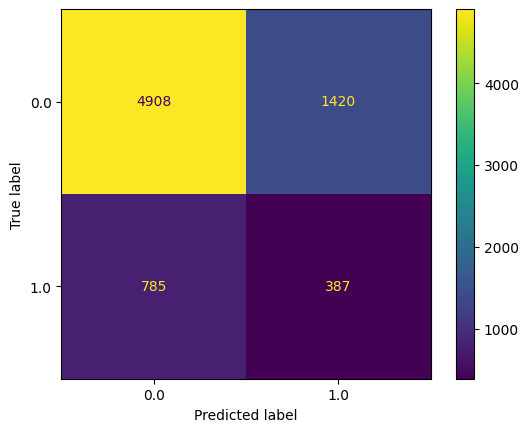

In [42]:
# Confusion Matrix and metrics
y_prob_dnn = results_df['Predicted'].values
y_pred_dnn = results_df['Predicted_Binary'].values

accuracy  = accuracy_score(y_test,  y_pred_dnn)
recall    = recall_score(y_test,    y_pred_dnn)
precision = precision_score(y_test, y_pred_dnn, zero_division=0)
f1        = f1_score(y_test,        y_pred_dnn, zero_division=0)
auc       = roc_auc_score(y_test,   y_prob_dnn)

print(f'Accuracy : {round(accuracy,  4)}')
print(f'Recall   : {round(recall,    4)}')
print(f'Precision: {round(precision, 4)}')
print(f'F1 Score : {round(f1,        4)}')
print(f'AUC-ROC  : {round(auc,       4)}')

CM.from_predictions(y_test, y_pred_dnn)


## 3.Model Comparison

---
**Model Comparison and Recommendation (Q3c & Q4)**

All three models were trained on the same data and evaluated on the same test set so the comparison is fair.

The key metrics for this problem are Recall and AUC-ROC rather than Accuracy. With 15.6% defaults, a model that predicts "repaid" for every loan would score ~84% accuracy while catching zero defaults. Recall tells us what fraction of actual defaults the model correctly flagged - every missed default is a direct financial loss.

In [43]:
# Collect results from all three models into one comparison table
results = {
    'Model'    : ['Logistic Regression', 'Basic DNN', 'Optimised DNN'],
    'Accuracy' : [round(accuracy_score(y_test, (y_prob_lr  >= 0.5).astype(int)), 4),
                  round(accuracy_score(y_test, (y_prob_dnn >= 0.5).astype(int)), 4),
                  round(accuracy_score(y_test, (y_prob_opt >= 0.5).astype(int)), 4)],
    'Recall'   : [round(recall_score(y_test, (y_prob_lr  >= 0.5).astype(int)), 4),
                  round(recall_score(y_test, (y_prob_dnn >= 0.5).astype(int)), 4),
                  round(recall_score(y_test, (y_prob_opt >= 0.5).astype(int)), 4)],
    'Precision': [round(precision_score(y_test, (y_prob_lr  >= 0.5).astype(int), zero_division=0), 4),
                  round(precision_score(y_test, (y_prob_dnn >= 0.5).astype(int), zero_division=0), 4),
                  round(precision_score(y_test, (y_prob_opt >= 0.5).astype(int), zero_division=0), 4)],
    'F1'       : [round(f1_score(y_test, (y_prob_lr  >= 0.5).astype(int), zero_division=0), 4),
                  round(f1_score(y_test, (y_prob_dnn >= 0.5).astype(int), zero_division=0), 4),
                  round(f1_score(y_test, (y_prob_opt >= 0.5).astype(int), zero_division=0), 4)],
    'AUC-ROC'  : [round(roc_auc_score(y_test, y_prob_lr),  4),
                  round(roc_auc_score(y_test, y_prob_dnn), 4),
                  round(roc_auc_score(y_test, y_prob_opt), 4)],
}

comparison_df = pd.DataFrame(results).set_index('Model')
print(comparison_df)


                     Accuracy  Recall  Precision      F1  AUC-ROC
Model                                                            
Logistic Regression    0.6060  0.4556     0.1873  0.2655   0.5587
Basic DNN              0.7060  0.3302     0.2142  0.2598   0.5821
Optimised DNN          0.7251  0.4181     0.2620  0.3222   0.6550


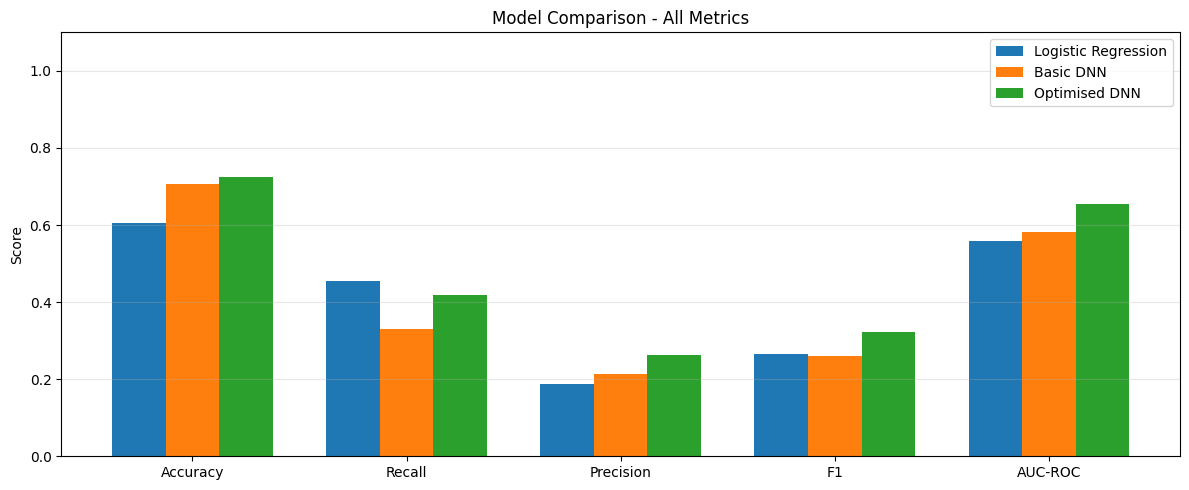

In [44]:
# Side by side bar chart for all metrics
metrics = ['Accuracy', 'Recall', 'Precision', 'F1', 'AUC-ROC']
x       = np.arange(len(metrics))
width   = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, comparison_df.loc['Logistic Regression', metrics], width, label='Logistic Regression')
ax.bar(x,         comparison_df.loc['Basic DNN',           metrics], width, label='Basic DNN')
ax.bar(x + width, comparison_df.loc['Optimised DNN',       metrics], width, label='Optimised DNN')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison - All Metrics')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


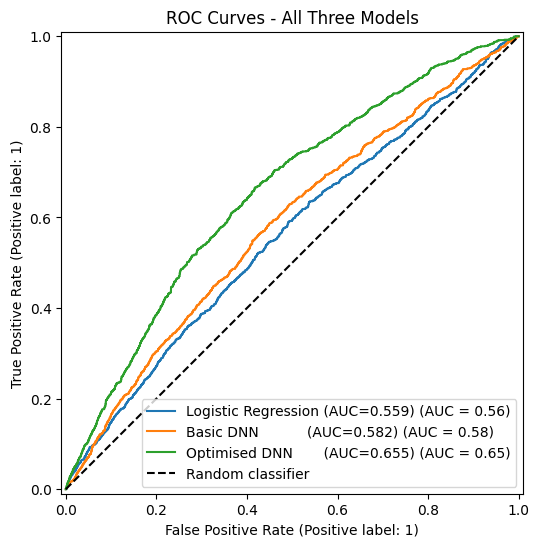

In [45]:
# ROC curves - all three models on the same axes
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(y_test, y_prob_lr,  name=f'Logistic Regression (AUC={round(roc_auc_score(y_test, y_prob_lr), 3)})',  ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_dnn, name=f'Basic DNN           (AUC={round(roc_auc_score(y_test, y_prob_dnn), 3)})', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_opt, name=f'Optimised DNN       (AUC={round(roc_auc_score(y_test, y_prob_opt), 3)})', ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_title('ROC Curves - All Three Models')
ax.legend(loc='lower right')
plt.show()


## 4.Q2 Borrower Clusters in all 3 models

**Performance by Q2 Borrower Cluster**
This tells us whether the model performs well across all borrower types or struggles with specific segments. High-Risk borrowers (Cluster 3) have a 29.4% default rate so recall here is especially important.

In [48]:
# Evaluate recall per cluster for each model
cluster_rows = []
for cl in sorted(np.unique(clusters_test)):
    mask = (clusters_test == cl)
    y_cl = y_test[mask]

    for model_name, y_prob in [('Logistic Regression', y_prob_lr),
                                ('Basic DNN',           y_prob_dnn),
                                ('Optimised DNN',       y_prob_opt)]:
        p_cl = y_prob[mask]
        pred = (p_cl >= 0.5).astype(int)
        cluster_rows.append({
            'Cluster'   : cluster_names[cl],
            'Def. Rate' : f'{y_cl.mean()*100:.1f}%',
            'N'         : int(mask.sum()),
            'Model'     : model_name,
            'Recall'    : round(recall_score(y_cl, pred), 3),
            'F1'        : round(f1_score(y_cl, pred, zero_division=0), 3),
            'AUC-ROC'   : round(roc_auc_score(y_cl, p_cl) if y_cl.sum() > 0 else np.nan, 3),
        })

cluster_df = pd.DataFrame(cluster_rows)
print(cluster_df.to_string(index=False))


              Cluster Def. Rate    N               Model  Recall    F1  AUC-ROC
     Cluster 0: Prime      9.0% 2177 Logistic Regression   0.123 0.111    0.487
     Cluster 0: Prime      9.0% 2177           Basic DNN   0.133 0.132    0.551
     Cluster 0: Prime      9.0% 2177       Optimised DNN   0.036 0.059    0.599
Cluster 1: Near-Prime     11.9% 1793 Logistic Regression   0.383 0.195    0.491
Cluster 1: Near-Prime     11.9% 1793           Basic DNN   0.215 0.183    0.534
Cluster 1: Near-Prime     11.9% 1793       Optimised DNN   0.042 0.072    0.600
 Cluster 2: Sub-Prime     19.7% 2877 Logistic Regression   0.537 0.289    0.505
 Cluster 2: Sub-Prime     19.7% 2877           Basic DNN   0.359 0.267    0.530
 Cluster 2: Sub-Prime     19.7% 2877       Optimised DNN   0.551 0.335    0.584
 Cluster 3: High-Risk     29.9%  653 Logistic Regression   0.631 0.385    0.492
 Cluster 3: High-Risk     29.9%  653           Basic DNN   0.569 0.402    0.492
 Cluster 3: High-Risk     29.9%  653    

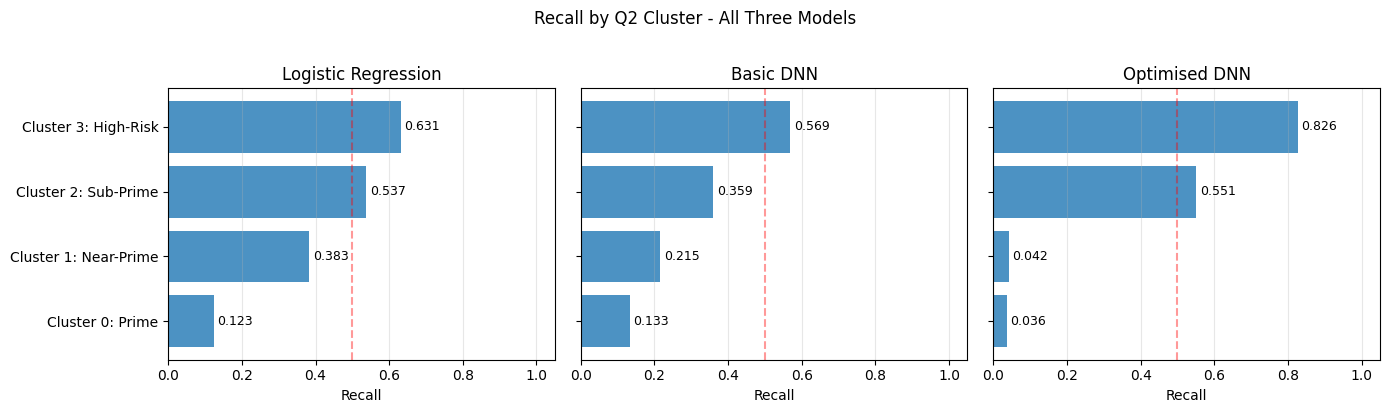

In [49]:
# Recall by cluster for each model
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
model_list = ['Logistic Regression', 'Basic DNN', 'Optimised DNN']

for ax, model_name in zip(axes, model_list):
    sub    = cluster_df[cluster_df['Model'] == model_name]
    labels = sub['Cluster'].values
    vals   = sub['Recall'].values
    ax.barh(labels, vals, alpha=0.8)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Recall')
    ax.set_title(model_name)
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.4)
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(v + 0.01, i, str(v), va='center', fontsize=9)

plt.suptitle('Recall by Q2 Cluster - All Three Models', y=1.02)
plt.tight_layout()
plt.show()
